Import libraries


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df=pd.read_csv('Mall_Customers.csv')

In [10]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
df.info

<bound method DataFrame.info of      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]>

In [12]:
missing_values = df.isnull().sum()
print(missing_values)

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [13]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]

In [14]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [45]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5,random_state=42)
clusters = kmeans.fit_predict(X)
print(clusters)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [46]:
print(kmeans.cluster_centers_)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


Text(0, 0.5, 'Spending Score (1-100)')

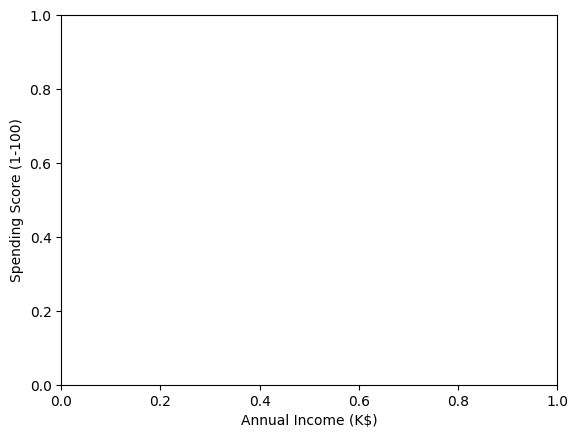

Text(0, 0.5, 'Spending Score (1-100)')

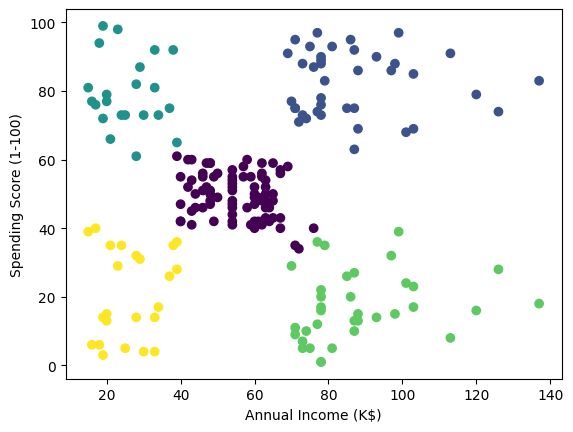

In [47]:
plt.scatter(X['Annual Income (k$)'],X['Spending Score (1-100)'],c=clusters)
plt.xlabel("Annual Income (K$)")
plt.ylabel("Spending Score (1-100)")

Knee locator manual 


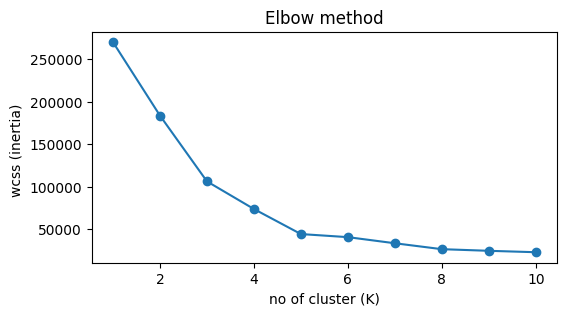

In [44]:
wcss = []

from sklearn.cluster import KMeans
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(6,3))
plt.plot(range(1,11),wcss,marker="o")
plt.title("Elbow method")
plt.xlabel("no of cluster (K)")
plt.ylabel("wcss (inertia) ")
plt.show()

Knee  Locator using library 


In [34]:
from kneed import KneeLocator
knee = KneeLocator(
    range(1,11),
    wcss,
    curve = "convex",
    direction = "decreasing"
)

print("optimal K:",knee.elbow)

optimal K: 5


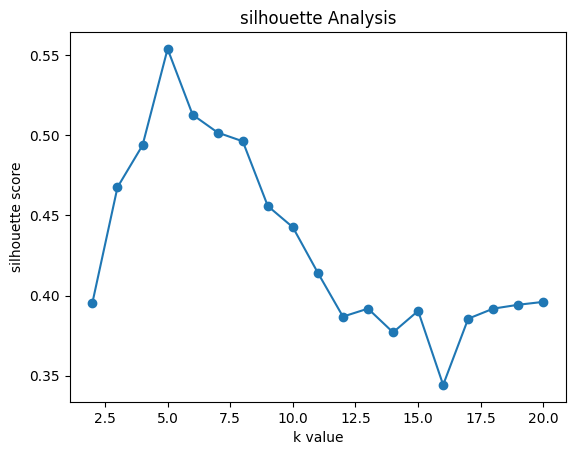

Best score: 0.553931997444648
Best k: 5


In [42]:
from sklearn.metrics import silhouette_score

scores = []
for k in range (2,21):
    model = KMeans(n_clusters=k,random_state=42)
    labels = model.fit_predict(X)
    score = silhouette_score(X,labels)
    scores.append(score)

plt.plot(range(2,21),scores,marker = 'o')
plt.xlabel("k value")
plt.ylabel("silhouette score")
plt.title("silhouette Analysis")
plt.show()

best_k = scores.index(max(scores))+2
print("Best score:",max(scores))
print("Best k:",best_k)
